# <font color='black'>Introduction to Machine Learning</font>

---

<img src="images/ipsa_logo.png" width="100" align="right">


> Year: **2025-2026**

> Contributors: **TO BE DECIDED**


## <font color='black'>Contents</font>

---
 
1. [Setting up the data](#Set-Up)
2. [A faire](#LinearRegression)
 * [Gradient Descent](#GD)
3. [A Faire](#LinearRegression2)
 * [Feature Scaling](#FeatureScaling)
 * [Gradient Descent](#GD2)
 * [Normal Equation](#NE)

Part 1:

## Set-Up
---
Let's first import the package we will need throughout this notebook.

In [31]:
#===================
# time wasted here: 5
# ==================

import numpy as np
import pandas as pd
import seaborn as sns
import time as t

import matplotlib.pyplot as plt 
import linear_regression as lr
import separate_data as sd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, mean_absolute_error

#tell jupiter to display plots in the notebook.
%matplotlib inline 

#tell jupyter to check for updates and reload the imported .py files
%load_ext autoreload
%autoreload 2
import importlib


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Let's now import and visualize the data.

In [32]:
t0 = t.perf_counter()
data = pd.read_parquet("./data/archive/Combined_Flights_2018.parquet")
load_time_parquet = t.perf_counter() - t0
print(f"Time to load the data: {load_time_parquet:.02f} sec.")

data.head()
before = data.shape
print(before)

Time to load the data: 12.45 sec.
(5689512, 61)


Part 2:

## Cleanup
---
Let's clean our data in this following part : 

In [33]:
# We are only interessted in flights that actually landed at the correct destination
data = data[(data['Cancelled'] == 0) & (data['Diverted'] == 0)]
data = data.drop(columns=['Cancelled', 'Diverted'])


# We're only keeping essential features :
cols_to_keep = [
    'Month', 'DayofMonth', 'DayOfWeek', 
    'Airline', 'Origin', 'Dest', 
    'CRSDepTime', 'Distance', 'DepDelay', 'ArrDelay'
]
data = data[cols_to_keep]

# Removing lines where the NaN values are presents in the target variables
data = data.dropna() # dropna = drop Not a Number (empty/missing values).


# Engineering des heures (Transformer HHMM en heures décimales toujours en base 24h)
# Exemple : 1530 devient 15.5 heures
"""data['DepHours'] = round(((data['CRSDepTime'] // 100) + (data['CRSDepTime'] %100)/60),2)""" 
# Temps tout en minutes (1202 devient 722 minutes)
data['DepHours'] = round(data['CRSDepTime'] // 100) * 60 + round((data['CRSDepTime'] % 100) / 60*60 )

data = data.drop(columns=['CRSDepTime'])


# Adding a binary feature (0,1) to indicate if there is a delay
data['IsDelay'] = (data['ArrDelay'] > 15).astype(int)

# Transforming text collums into categorys for memory optimisation
for col in ['Airline', 'Origin', 'Dest']:
    data[col] = data[col].astype('category')

after = data.shape
print(data.shape)
print(before[0]-after[0])
print(data.head(10))

(5585544, 11)
103968
    Month  DayofMonth  DayOfWeek            Airline Origin Dest  Distance  \
0       1          23          2  Endeavor Air Inc.    ABY  ATL     145.0   
1       1          24          3  Endeavor Air Inc.    ABY  ATL     145.0   
2       1          25          4  Endeavor Air Inc.    ABY  ATL     145.0   
3       1          26          5  Endeavor Air Inc.    ABY  ATL     145.0   
4       1          27          6  Endeavor Air Inc.    ABY  ATL     145.0   
6       1          29          1  Endeavor Air Inc.    ABY  ATL     145.0   
7       1          30          2  Endeavor Air Inc.    ABY  ATL     145.0   
9       1           3          3  Endeavor Air Inc.    ATL  ABY     145.0   
10      1           4          4  Endeavor Air Inc.    ATL  ABY     145.0   
11      1           5          5  Endeavor Air Inc.    ATL  ABY     145.0   

    DepDelay  ArrDelay  DepHours  IsDelay  
0       -5.0      -8.0     722.0        0  
1       -5.0      -6.0     722.0        0  

Part 3:

## EDA : 
---

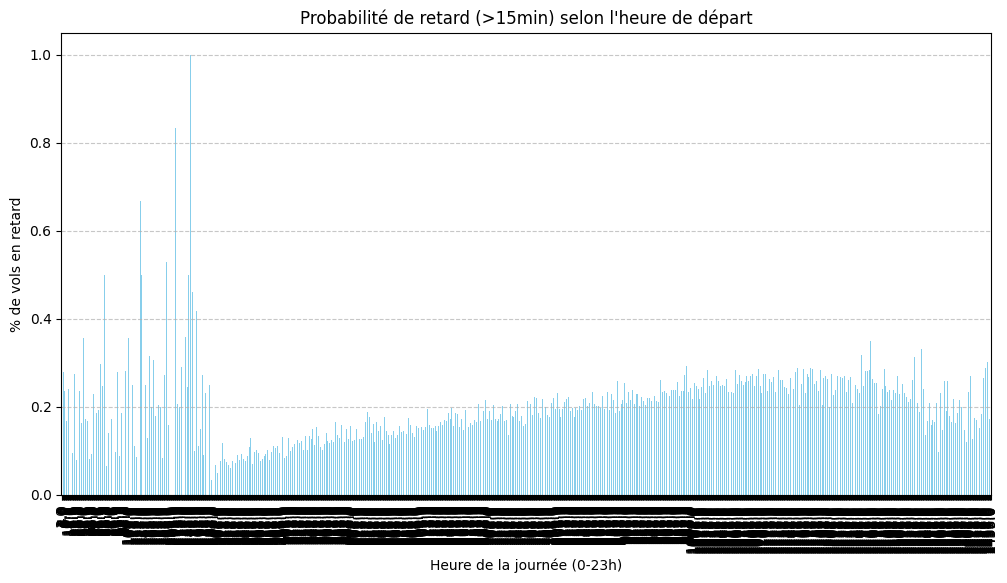

In [34]:
plt.figure(figsize=(12, 6))

hourly_stats = data.groupby('DepHours')['IsDelay'].mean()
hourly_stats.plot(kind='bar', color='skyblue')

plt.title("Probabilité de retard (>15min) selon l'heure de départ")
plt.xlabel("Heure de la journée (0-23h)")
plt.ylabel("% de vols en retard")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

LINEAR REGRESSION :

La matrice de données a été mélangée
La matrice de données a été réduite à 3.0% de sa taille initiale
la taille de la matrice de data utilisée est : (167566, 771)


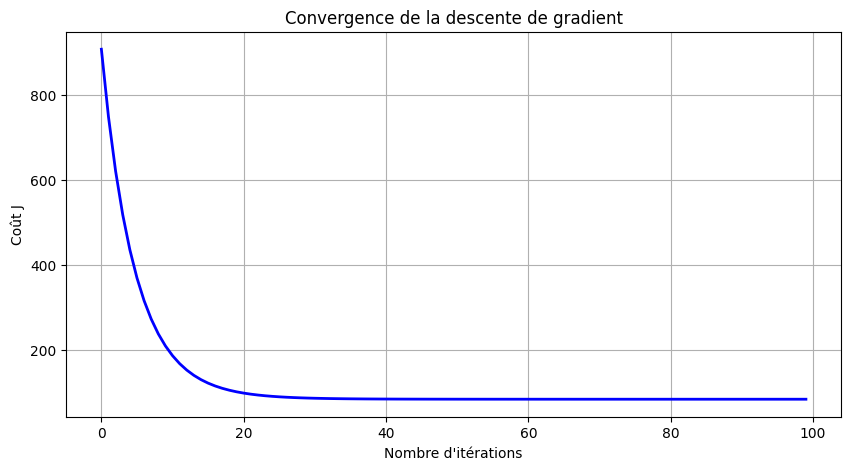


--- ÉVALUATION RÉGRESSION (Seuil 5 min) ---

--- Comparaison Regression (Seuil de 5min) ---
   Prédiction (min)  Réalité (min)
0        -10.201085            4.0
1         10.618868           11.0
2         -8.300504            4.0
3        453.805947          449.0
4          0.093081            5.0
Accuracy de la regression pour un seuil de 5 minutes: 38.78 %
Erreur moyenne (MAE) : 9.15 min | Erreur quadratique (RMSE) : 13.04 min

--- ÉVALUATION CLASSIFICATION (Seuil de 5 min) ---

--- Comparaison Classification (Seuil de 5min) ---
  Prédiction    Réalité  Correct ?
0  À l'heure  À l'heure       True
1    Retardé    Retardé       True
2  À l'heure  À l'heure       True
3    Retardé    Retardé       True
4  À l'heure  À l'heure       True

Matrice de Confusion :
Vrais Négatifs (À l'heure) : 23225 | Faux Positifs : 983
Faux Négatifs : 3042 | Vrais Positifs (Retards détectés) : 6264

Accuracy de la classification pour un seuil de 5 minutes: 87.99 %


In [46]:
#reloading des modules 
importlib.reload(lr)
importlib.reload(sd)

# Séparation et préparation des données
X_train, X_test, y_tr_reg, y_te_reg, y_tr_cl, y_te_cl = lr.call_data_preparation(data, size=0.03)

# Normalisation et Intercept
X_train_f, X_test_f = lr.normalisation(X_train, X_test)

# Entraînement
alpha = 0.1
num_iters = 100
theta_init = np.zeros(X_train_f.shape[1])

theta_f, J_hist = lr.gradientDescentMulti(X_train_f, y_tr_reg, theta_init, alpha, num_iters)


# Visualisation de la connvergence
lr.visualisation_conv(J_hist)


# Prédiction et Scores
preds = lr.predict_and_evaluate(X_test_f, y_te_reg, theta_f, seuil=5)